# Example of likelihood calculation for BAO

In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations

# cloelike imports
from cloelike.EuclidLikelihood_GCspectro_BAO import EuclidLikelihood_GCspectro_BAO

# euclidlib imports
from euclidlib.le3.bao_gc import BAO_alphas, BAO_alphas_covariance

### Download the data from Zenodo

In [3]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'bao_z1.00.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_ALPHAS_Z1.0.fits',
        'bao_z1.20.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_ALPHAS_Z1.2.fits',
        'bao_z1.40.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_ALPHAS_Z1.4.fits',
        'bao_z1.65.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_ALPHAS_Z1.65.fits',
        'cov_z1.00.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_COV_Z1.0.fits',
        'cov_z1.20.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_COV_Z1.2.fits',
        'cov_z1.40.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_COV_Z1.4.fits',
        'cov_z1.65.fits': 'https://zenodo.org/records/19729182/files/EUC_LE3_BAO_COV_Z1.65.fits',
    }

    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

Load the datafiles and construct a `data{'BAO'}` dictionary. We also store the fiducial cosmology, assuming it is shared among all redshift bins (this is also an assumption in the likelihood).

In [4]:
redshifts = [1.00, 1.20, 1.40, 1.65]
labels = [f"{z:.2f}" for z in redshifts]

# This uses the functionality of euclidlib of reading multiple files at the same time.
# We read the data vectors and the covariance matrices.
filename = 'bao_z{}.fits'
datavec_BAO = BAO_alphas(filename, *labels)

filename = 'cov_z{}.fits'
covariance = BAO_alphas_covariance(filename, *labels)

# We hand over the euclidlib objects directly to the likelihood module, which takes care
# of properly arranging them
data = {
    'GCspectro': {
        z: {
            'datavec': datavec_BAO[('SPE', 'SPE', ii, ii)],
            'covariance': covariance[('SPE', 'SPE', ii, ii)],
        }
        for ii, z in enumerate(labels)
    }
}

Visualise the structure of the data dictionary

In [5]:
data

{'GCspectro': {'1.00': {'datavec': BaryonAcousticOscillations(alpha_par=array([1.], dtype='>f8'), alpha_perp=array([1.], dtype='>f8'), alpha_iso=array([nan], dtype='>f8'), alpha_ap=array([nan], dtype='>f8'), fiducial_cosmology={'H0': 67.0, 'Omega_m0': 0.319, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'ns': 0.96, 'sigma_8': 0.83, 'As': None, 'w0': -1.0, 'wa': 0.0, 'N_mnu': 0, 'mnu': 0.0}, zeff=1.0),
   'covariance': BaryonAcousticOscillationsCovariance(observables=[np.str_('ALPHA_PAR'), np.str_('ALPHA_PERP')], covariance={'ALPHA_PAR-ALPHA_PAR': np.float64(0.00094), 'ALPHA_PAR-ALPHA_PERP': np.float64(-0.00022), 'ALPHA_PERP-ALPHA_PAR': np.float64(-0.00022), 'ALPHA_PERP-ALPHA_PERP': np.float64(0.00029)}, correction_factor=1.0, zeff=1.0)},
  '1.20': {'datavec': BaryonAcousticOscillations(alpha_par=array([1.], dtype='>f8'), alpha_perp=array([1.], dtype='>f8'), alpha_iso=array([nan], dtype='>f8'), alpha_ap=array([nan], dtype='>f8'), fiducial_cosmology={'H0': 67.0, 'Omega_m0': 0.319, 'Omega_b0': 0.04

## Create an `EuclidLikelihood_BAO` object

This needs in input a data dictionary, the Background and LinearPerturbations type; here we use `CAMBBackground` and `CAMBLinearPerturbations`:

In [7]:
like_bao = EuclidLikelihood_GCspectro_BAO(data=data, Background=CAMBBackground, LinearPerturbations=CAMBLinearPerturbations)
#vars(like_bao)

## Timing the initialisation of the `EuclidLikelihood_BAO` object and the likelihood evaluation
These mainly depend on the type of `Background` used

In [9]:
print("⏱️ Timing initialisation with CAMB:")
%timeit like_bao = EuclidLikelihood_GCspectro_BAO(data=data, Background=CAMBBackground, LinearPerturbations=CAMBLinearPerturbations)

⏱️ Timing initialisation with CAMB:
376 ms ± 8.51 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0, 'N_mnu': 0,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    }

like_bao = EuclidLikelihood_GCspectro_BAO(data=data, Background=CAMBBackground, LinearPerturbations=CAMBLinearPerturbations)

print("⏱️ Timing log-likelihood evaluation:")

%timeit loglike_val = like_bao.loglike(parameters)

loglike_val = like_bao.loglike(parameters)
print(f"Log-likelihood: {loglike_val}")
print(f"-2 * log-likelihood: {-2 * loglike_val}")

⏱️ Timing log-likelihood evaluation:
3.88 ms ± 6.81 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Log-likelihood: -0.0
-2 * log-likelihood: 0.0


Compute the $\chi^2$ for different values of the parameters:

In [12]:
from IPython.display import display, Math

def print_chi2(parameters, like, description):
    chi2 = -2 * like.loglike(parameters)
    print(f"🔧 {description}")
    display(Math(r"\chi^2 = {:.3f}".format(chi2)))
    print("-" * 40)

# Starting from original parameters dict
params = parameters.copy()  # to avoid modifying original dict if needed

# 1. Change H0 to 70.0
params['H0'] = 68.0
print_chi2(params, like_bao, "Changed H0 to 70.0")

# 2. Change w0 to -1.2
params['w0'] = -1.2
print_chi2(params, like_bao, "Set w0 to -1.2")

# 4. Change Omega_k0 to 0.2
params['Omega_k0'] = 0.2
print_chi2(params, like_bao, "Set Omega_k0 to 0.2")

🔧 Changed H0 to 70.0


<IPython.core.display.Math object>

----------------------------------------
🔧 Set w0 to -1.2


<IPython.core.display.Math object>

----------------------------------------
🔧 Set Omega_k0 to 0.2


<IPython.core.display.Math object>

----------------------------------------


Computing likelihood: 100%|████████████████████████████| 200/200 [00:00<00:00, 261.13it/s]


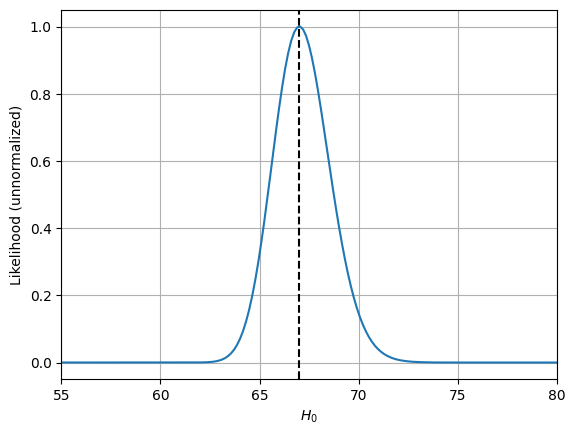

In [14]:
from tqdm import tqdm
like = EuclidLikelihood_GCspectro_BAO(data=data, Background=CAMBBackground, LinearPerturbations=CAMBLinearPerturbations)

H0_vals = np.linspace(50, 80, 200)
loglike_vals = []

for val in tqdm(H0_vals, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    parameters['H0'] = val
    loglike_vals.append(like.loglike(parameters))

loglike_vals = np.array(loglike_vals)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals = np.exp(loglike_vals - np.max(loglike_vals))  # subtract max for numerical stability

plt.plot(H0_vals, likelihood_vals)
plt.axvline(67, color='k', ls='--')
plt.xlim([55, 80])
plt.grid(True)
plt.xlabel(r'$H_0$')
plt.ylabel('Likelihood (unnormalized)')
plt.show()